In [1]:
!pip install folium
!pip install seaborn
!pip install kagglehub

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import objects as obj
import warnings
warnings.filterwarnings("ignore")


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "climate_change.csv"

# Download latest version
path = kagglehub.dataset_download("dastgeerjutt/global-climate-change-and-extreme-weather-impact")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\aless\.cache\kagglehub\datasets\dastgeerjutt\global-climate-change-and-extreme-weather-impact\versions\1


In [4]:
df = pd.read_csv("global_climate_change_extreme_weather_2026.csv")

In [5]:
df.describe(include="all")

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
count,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.00000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.0
unique,5000,10,6,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CLM0001,Germany,Asia,NaN,NaN,NaN,NaN,Low,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,542,1453,NaN,NaN,NaN,NaN,1731,1724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,17.491040,1.493576,3145.744600,3.49663,NaN,NaN,32.407400,148.337800,0.881200,175.280200,57.60100,150.177160,2026.0
std,NaN,NaN,NaN,7.203599,0.576416,1640.113354,1.42864,NaN,NaN,16.263343,87.615102,86.708135,72.615251,22.02999,86.287074,0.0
min,NaN,NaN,NaN,5.000000,0.500000,301.000000,1.00000,NaN,NaN,5.000000,0.000000,-150.000000,50.000000,20.00000,1.100000,2026.0
25%,NaN,NaN,NaN,11.300000,0.990000,1708.750000,2.26000,NaN,NaN,18.000000,70.000000,-73.000000,112.000000,39.00000,78.200000,2026.0
50%,NaN,NaN,NaN,17.400000,1.480000,3173.000000,3.52000,NaN,NaN,32.000000,149.000000,2.000000,175.000000,58.00000,149.750000,2026.0
75%,NaN,NaN,NaN,23.800000,1.990000,4552.500000,4.74000,NaN,NaN,47.000000,223.000000,76.000000,239.000000,77.00000,225.025000,2026.0


In [6]:
df.dtypes

record_id                    str
country                      str
region                       str
avg_temperature_c        float64
temperature_change_c     float64
co2_emissions_mt           int64
sea_level_rise_mm        float64
flood_risk                   str
drought_risk                 str
heatwave_days              int64
wildfire_incidents         int64
rainfall_change_mm         int64
air_quality_index          int64
climate_risk_score         int64
population_affected_m    float64
year                       int64
dtype: object

In [7]:
df.isna().any()

record_id                False
country                  False
region                   False
avg_temperature_c        False
temperature_change_c     False
co2_emissions_mt         False
sea_level_rise_mm        False
flood_risk               False
drought_risk             False
heatwave_days            False
wildfire_incidents       False
rainfall_change_mm       False
air_quality_index        False
climate_risk_score       False
population_affected_m    False
year                     False
dtype: bool

In [8]:
df.head()

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
0,CLM0001,Canada,North America,16.8,2.40,5477,1.44,Low,High,9,25,-117,127,89,92.7,2026
1,CLM0002,Brazil,South America,28.8,1.51,3758,1.55,Medium,Medium,38,197,73,103,81,95.4,2026
2,CLM0003,Australia,Oceania,6.6,1.70,1904,5.81,Medium,Medium,20,161,127,253,71,32.0,2026
3,CLM0004,Germany,Europe,10.9,1.53,3786,5.41,Medium,Low,56,191,-57,166,57,131.5,2026
4,CLM0005,United States,North America,13.9,2.07,732,3.20,High,High,42,76,-22,142,81,93.4,2026


In [9]:

df["country"].value_counts().idxmax

<bound method Series.idxmax of country
Germany           542
Brazil            520
Australia         502
United States     502
United Kingdom    499
Canada            496
Pakistan          492
Nigeria           486
China             485
India             476
Name: count, dtype: int64>

In [10]:
#"temperature_change_c"
country = df.groupby(["country"])[["avg_temperature_c", "co2_emissions_mt", "sea_level_rise_mm", "heatwave_days", "wildfire_incidents",	"rainfall_change_mm", "air_quality_index", "climate_risk_score", "population_affected_m"]].mean()
country

,avg_temperature_c,co2_emissions_mt,sea_level_rise_mm,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m
country,,,,,,,,,
Australia,17.017729,3125.243028,3.498347,32.412351,155.350598,1.565737,177.139442,57.908367,145.960757
Brazil,17.362692,3174.705769,3.450038,31.728846,146.321154,3.401923,171.061538,55.905769,150.950385
Canada,17.603024,3121.453629,3.575806,32.479839,148.054435,1.600806,178.778226,58.441532,148.876411
China,17.880000,3141.352577,3.532124,32.639175,144.600000,-10.630928,168.484536,59.880412,153.198969
Germany,18.143911,3106.608856,3.489207,32.151292,150.247232,1.223247,179.352399,57.232472,147.804797
India,17.211555,3143.577731,3.534181,32.861345,144.764706,2.731092,175.161765,56.556723,155.849790
Nigeria,17.333745,3050.681070,3.454897,32.833333,144.687243,6.862140,175.473251,57.911523,147.832922
Pakistan,17.522967,3236.997967,3.389675,32.315041,147.550813,-0.741870,173.455285,58.237805,149.165041
United Kingdom,16.996393,3146.012024,3.489579,32.446894,149.639279,2.809619,178.358717,56.541082,151.418637


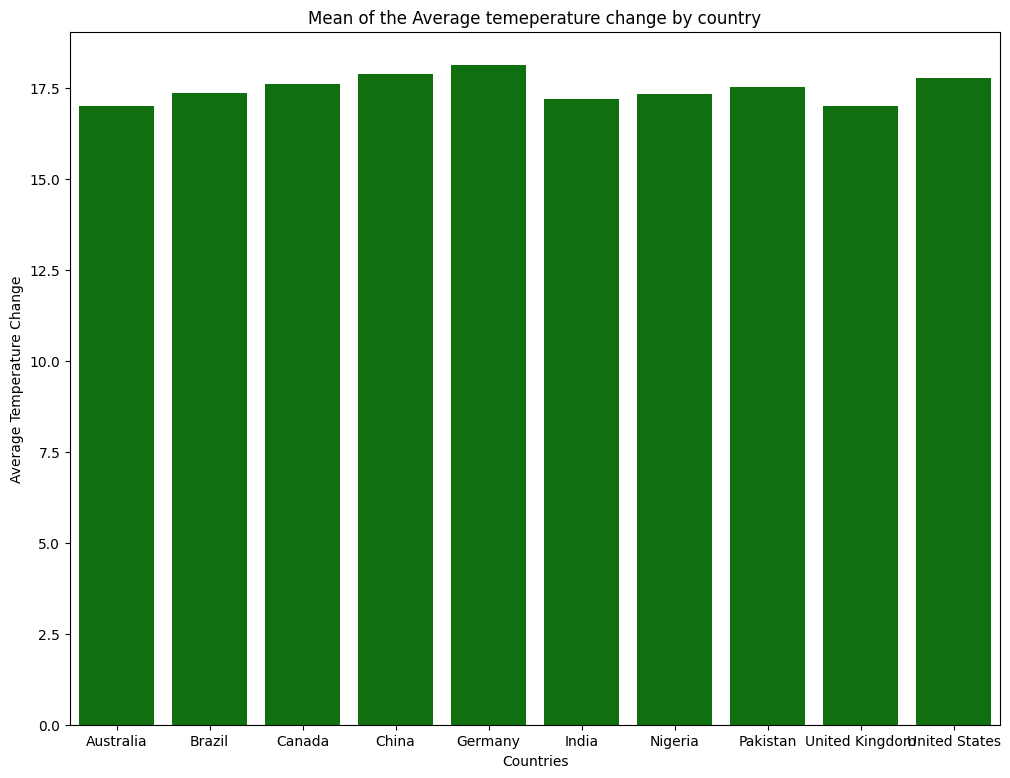

In [11]:
plt.figure(figsize=(12, 9))
sns.barplot(data=country, x="country", y="avg_temperature_c", fill=True, color="green")
plt.xlabel("Countries")
plt.ylabel("Average Temperature Change")
plt.title("Mean of the Average temeperature change by country")
plt.show()


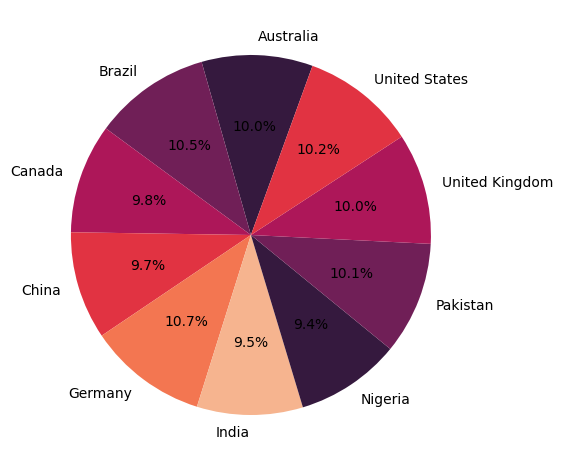

In [12]:
co2_sea = df.groupby("country")[["co2_emissions_mt", "sea_level_rise_mm"]].sum()
colors = sns.color_palette("rocket")
plt.pie(co2_sea["co2_emissions_mt"], labels=co2_sea.index, colors=colors, autopct='%1.1f%%', startangle=70)
plt.tight_layout()
plt.show()

In [13]:
df.head()

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
0,CLM0001,Canada,North America,16.8,2.40,5477,1.44,Low,High,9,25,-117,127,89,92.7,2026
1,CLM0002,Brazil,South America,28.8,1.51,3758,1.55,Medium,Medium,38,197,73,103,81,95.4,2026
2,CLM0003,Australia,Oceania,6.6,1.70,1904,5.81,Medium,Medium,20,161,127,253,71,32.0,2026
3,CLM0004,Germany,Europe,10.9,1.53,3786,5.41,Medium,Low,56,191,-57,166,57,131.5,2026
4,CLM0005,United States,North America,13.9,2.07,732,3.20,High,High,42,76,-22,142,81,93.4,2026


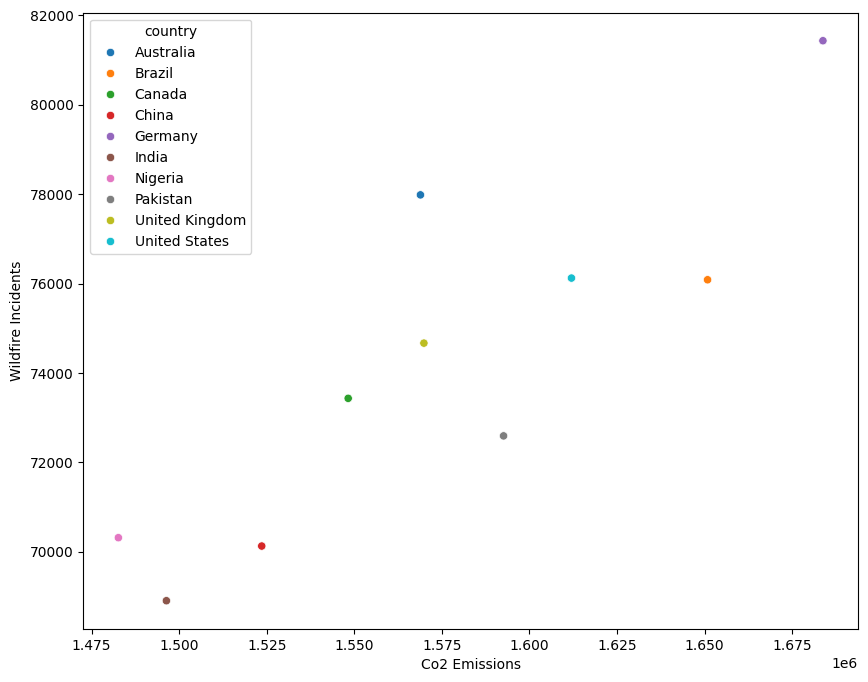

In [14]:
plt.figure(figsize=(10, 8))
emi = df.groupby("country")[["co2_emissions_mt", "wildfire_incidents"]].sum()
sns.scatterplot(data=emi, x="co2_emissions_mt", y="wildfire_incidents", hue="country")
plt.xlabel("Co2 Emissions")
plt.ylabel("Wildfire Incidents")
plt.show()

In [15]:
country.head()
#sns.color_palette("rocket")

,avg_temperature_c,co2_emissions_mt,sea_level_rise_mm,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m
country,,,,,,,,,
Australia,17.017729,3125.243028,3.498347,32.412351,155.350598,1.565737,177.139442,57.908367,145.960757
Brazil,17.362692,3174.705769,3.450038,31.728846,146.321154,3.401923,171.061538,55.905769,150.950385
Canada,17.603024,3121.453629,3.575806,32.479839,148.054435,1.600806,178.778226,58.441532,148.876411
China,17.880000,3141.352577,3.532124,32.639175,144.600000,-10.630928,168.484536,59.880412,153.198969
Germany,18.143911,3106.608856,3.489207,32.151292,150.247232,1.223247,179.352399,57.232472,147.804797


In [16]:
country.reset_index(inplace=True)

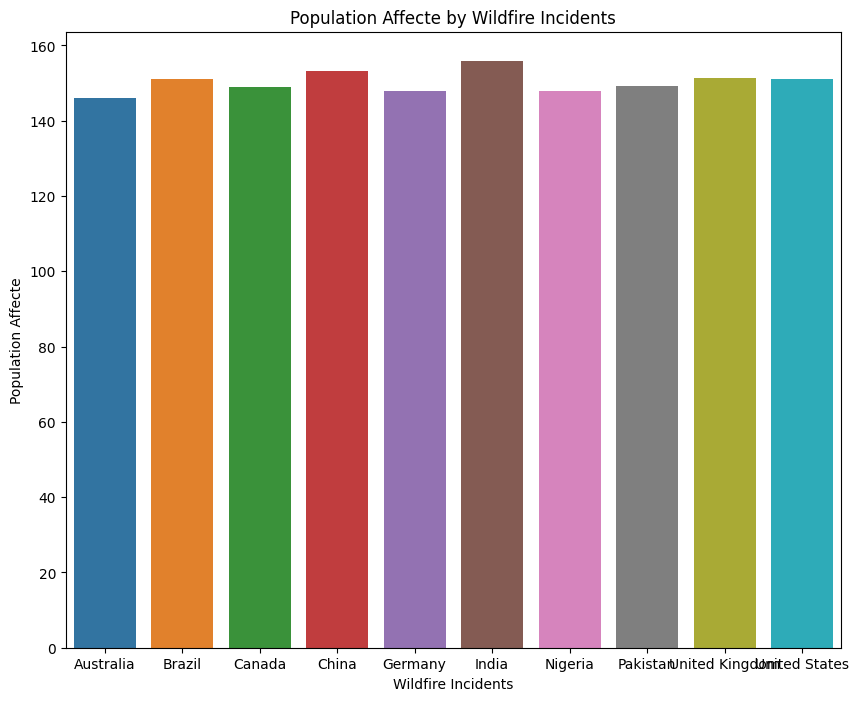

In [17]:
plt.figure(figsize=(10,8))
sns.barplot(data=country, x="country", y="population_affected_m", hue="country")
plt.xlabel("Wildfire Incidents")
plt.ylabel("Population Affecte")
plt.title("Population Affecte by Wildfire Incidents")
plt.show()

In [18]:
country.head()

,country,avg_temperature_c,co2_emissions_mt,sea_level_rise_mm,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m
0,Australia,17.017729,3125.243028,3.498347,32.412351,155.350598,1.565737,177.139442,57.908367,145.960757
1,Brazil,17.362692,3174.705769,3.450038,31.728846,146.321154,3.401923,171.061538,55.905769,150.950385
2,Canada,17.603024,3121.453629,3.575806,32.479839,148.054435,1.600806,178.778226,58.441532,148.876411
3,China,17.880000,3141.352577,3.532124,32.639175,144.600000,-10.630928,168.484536,59.880412,153.198969
4,Germany,18.143911,3106.608856,3.489207,32.151292,150.247232,1.223247,179.352399,57.232472,147.804797


In [19]:
fd_risk = df.groupby(["flood_risk", "drought_risk"])[["avg_temperature_c", "co2_emissions_mt", "sea_level_rise_mm", "heatwave_days", "wildfire_incidents",	"rainfall_change_mm", "air_quality_index", "climate_risk_score", "population_affected_m"]].sum()

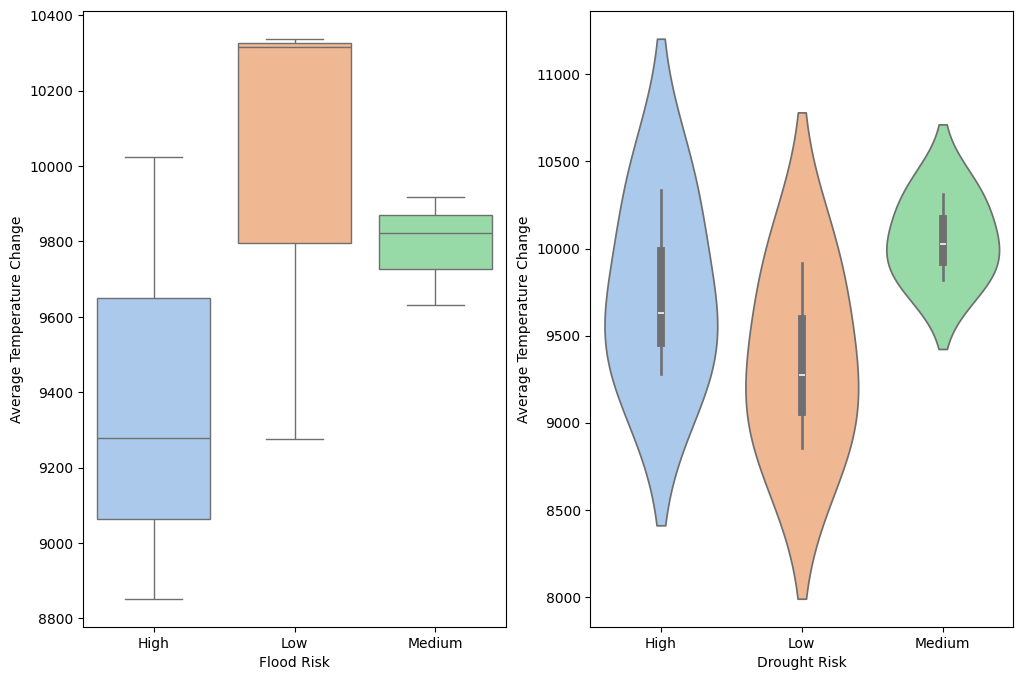

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

sns.boxplot(ax=axes[0], data=fd_risk, x="flood_risk", y="avg_temperature_c", palette="pastel")
axes[0].set_xlabel("Flood Risk")
axes[0].set_ylabel("Average Temperature Change")
sns.violinplot(ax=axes[1], data=fd_risk, x="drought_risk", y="avg_temperature_c", palette="pastel")
axes[1].set_xlabel("Drought Risk")
axes[1].set_ylabel("Average Temperature Change")

plt.show()

In [21]:
country.head()

,country,avg_temperature_c,co2_emissions_mt,sea_level_rise_mm,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m
0,Australia,17.017729,3125.243028,3.498347,32.412351,155.350598,1.565737,177.139442,57.908367,145.960757
1,Brazil,17.362692,3174.705769,3.450038,31.728846,146.321154,3.401923,171.061538,55.905769,150.950385
2,Canada,17.603024,3121.453629,3.575806,32.479839,148.054435,1.600806,178.778226,58.441532,148.876411
3,China,17.880000,3141.352577,3.532124,32.639175,144.600000,-10.630928,168.484536,59.880412,153.198969
4,Germany,18.143911,3106.608856,3.489207,32.151292,150.247232,1.223247,179.352399,57.232472,147.804797


Text(0.5, 0, 'Climate risk score')

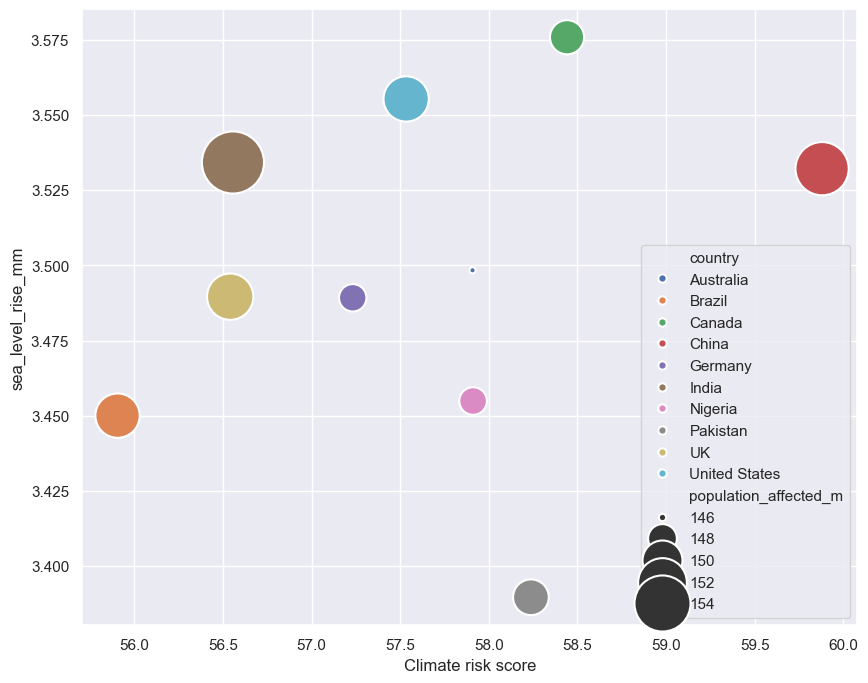

In [36]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,8))
# use the scatterplot function to build the bubble map
country.country = ['Australia',
 'Brazil',
 'Canada',
 'China',
 'Germany',
 'India',
 'Nigeria',
 'Pakistan',
 'UK',
 'United States']
sns.scatterplot(
    data=country,
    x="climate_risk_score",
    y="sea_level_rise_mm",
    size="population_affected_m",
    legend=True,
    sizes=(20, 2000),
    hue="country"
)
plt.xlabel("Climate risk score")
